In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('chatgpt_reviews.csv')


In [ ]:
print(df.head())

                              Review Id  \
0  6fb93778-651a-4ad1-b5ed-67dd0bd35aac   
1  81caeefd-3a28-4601-a898-72897ac906f5   
2  452af49e-1d8b-4b68-b1ac-a94c64cb1dd5   
3  372a4096-ee6a-4b94-b046-cef0b646c965   
4  b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da   

                                              Review  Ratings  \
0                                               good      5.0   
1                                               good      5.0   
2                                           nice app      5.0   
3                                           nice, ig      5.0   
4  this is a great app, the bot is so accurate to...      5.0   

           Review Date  
0  2024-08-23 19:30:05  
1  2024-08-23 19:28:18  
2  2024-08-23 19:22:59  
3  2024-08-23 19:20:50  
4  2024-08-23 19:20:39  


In [ ]:
print(df.shape)

(136201, 4)


In [ ]:
print(df.columns)

Index(['Review Id', 'Review', 'Ratings', 'Review Date'], dtype='object')


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 133907 entries, 0 to 136199
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Review Id    133907 non-null  object 
 1   Review       133907 non-null  object 
 2   Ratings      133907 non-null  float64
 3   Review Date  133907 non-null  object 
dtypes: float64(1), object(3)
memory usage: 5.1+ MB
None


In [ ]:
df["Review Date"] = pd.to_datetime(df["Review Date"])

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 133907 entries, 0 to 136199
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Review Id    133907 non-null  object        
 1   Review       133907 non-null  object        
 2   Ratings      133907 non-null  float64       
 3   Review Date  133907 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 5.1+ MB
None


In [ ]:
null_percent = (df.isnull().sum() / len(df)) * 100
print(null_percent)

Review Id      0.000000
Review         0.001468
Ratings        0.000734
Review Date    0.000734
dtype: float64


In [ ]:
df = df.dropna()

In [ ]:
print(df.duplicated().sum())

2291


In [ ]:
duplicates = df[df.duplicated()]
duplicates.head(10)

,Review Id,Review,Ratings,Review Date
79518,cb1c2e68-8d30-4361-a6d6-2ee0cedc6522,The best app ever,5.0,2024-05-17 12:14:35
79519,54c7f809-bc21-4a4e-8370-5c2c5f4feedb,chup saale,1.0,2024-05-17 12:14:05
79520,d24a6482-0ec4-4e09-b576-03ea87f8a702,very useful,5.0,2024-05-17 12:13:47
79521,d1072c90-f7a6-4556-b070-419c787d4b9c,Fantastic,5.0,2024-05-17 12:13:22
79522,a615f86c-49a5-45d5-a2e1-1816b550b3ca,أفضل موقع لي المعلومات 👍,5.0,2024-05-17 12:11:50
79523,a2ad6544-3a4c-4cb9-b33f-1751ec4cd951,good,5.0,2024-05-17 12:11:08
79524,13c7e2e8-9af7-47fa-809d-51d0e108c14e,superb,5.0,2024-05-17 12:10:37
79525,a8d93433-b9c9-4926-b61e-c502b9d8907b,Too po**,5.0,2024-05-17 12:10:19
79526,570d1478-124a-40ce-b1ca-019252c49d37,"Why it's saying ""you have reached chat-GPT rat...",1.0,2024-05-17 12:09:38
79527,7b6e5b27-fb51-45b9-84ce-3ef89c9efce4,good,5.0,2024-05-17 12:09:17


In [ ]:
df[df.duplicated(keep=False)].head(20)

,Review Id,Review,Ratings,Review Date
78852,cb1c2e68-8d30-4361-a6d6-2ee0cedc6522,The best app ever,5.0,2024-05-17 12:14:35
78853,54c7f809-bc21-4a4e-8370-5c2c5f4feedb,chup saale,1.0,2024-05-17 12:14:05
78854,d24a6482-0ec4-4e09-b576-03ea87f8a702,very useful,5.0,2024-05-17 12:13:47
78855,d1072c90-f7a6-4556-b070-419c787d4b9c,Fantastic,5.0,2024-05-17 12:13:22
78856,a615f86c-49a5-45d5-a2e1-1816b550b3ca,أفضل موقع لي المعلومات 👍,5.0,2024-05-17 12:11:50
78857,a2ad6544-3a4c-4cb9-b33f-1751ec4cd951,good,5.0,2024-05-17 12:11:08
78858,13c7e2e8-9af7-47fa-809d-51d0e108c14e,superb,5.0,2024-05-17 12:10:37
78859,a8d93433-b9c9-4926-b61e-c502b9d8907b,Too po**,5.0,2024-05-17 12:10:19
78860,570d1478-124a-40ce-b1ca-019252c49d37,"Why it's saying ""you have reached chat-GPT rat...",1.0,2024-05-17 12:09:38
78861,7b6e5b27-fb51-45b9-84ce-3ef89c9efce4,good,5.0,2024-05-17 12:09:17


In [ ]:
df[df["Review Id"] == "cb1c2e68-8d30-4361-a6d6-2ee0cedc6522"]

,Review Id,Review,Ratings,Review Date
78852,cb1c2e68-8d30-4361-a6d6-2ee0cedc6522,The best app ever,5.0,2024-05-17 12:14:35
79518,cb1c2e68-8d30-4361-a6d6-2ee0cedc6522,The best app ever,5.0,2024-05-17 12:14:35


In [ ]:
df = df.drop_duplicates()

In [ ]:
print(df.duplicated().sum())

0


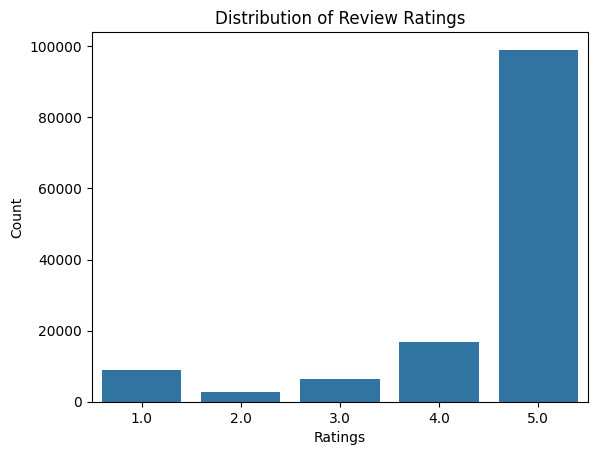

In [ ]:
sns.countplot(data=df, x='Ratings')
plt.title('Distribution of Review Ratings')
plt.xlabel('Ratings')
plt.ylabel('Count')
plt.show()

#### **Interpretation: Distribution of Review Ratings**
This graph shows that a vast majority of reviews are positive (5-star ratings), followed by 1-star ratings. There are very few neutral (3-star) and moderately positive (4-star) reviews, and almost no 2-star reviews. This suggests a polarized user base, where users either love the app or strongly dislike it, with little in-between.

In [ ]:
df['review_length'] = df['Review'].apply(len)
print(df['review_length'].head(10))

0      4
1      4
2      8
3      8
4    368
5     11
6     26
7      9
8     15
9     53
Name: review_length, dtype: int64


In [ ]:
df[["Review", "review_length"]].head()

,Review,review_length
0,good,4
1,good,4
2,nice app,8
3,"nice, ig",8
4,"this is a great app, the bot is so accurate to...",368


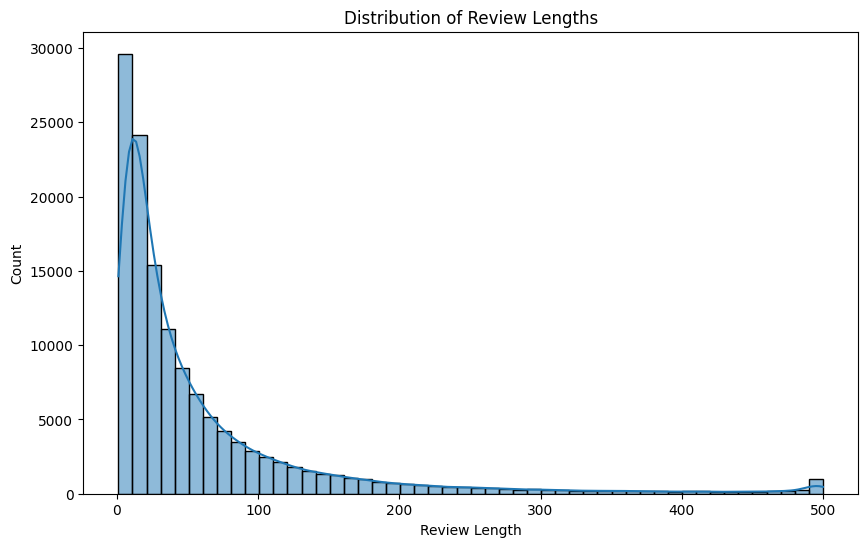

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='review_length', bins=50, kde=True)
plt.title('Distribution of Review Lengths')
plt.xlabel('Review Length')
plt.ylabel('Count')
plt.show()

#### **Interpretation: Distribution of Review Lengths**
The histogram indicates that most reviews are very short, likely consisting of just a few words. There's a rapid decrease in frequency as review length increases, with a long tail indicating a few very lengthy reviews. This suggests that users typically leave quick feedback, with only a small segment providing detailed comments.

In [ ]:
df['month'] = df['Review Date'].dt.month
df['day_of_week'] = df['Review Date'].dt.dayofweek

/tmp/ipykernel_1400/3625520919.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='month', palette='viridis')


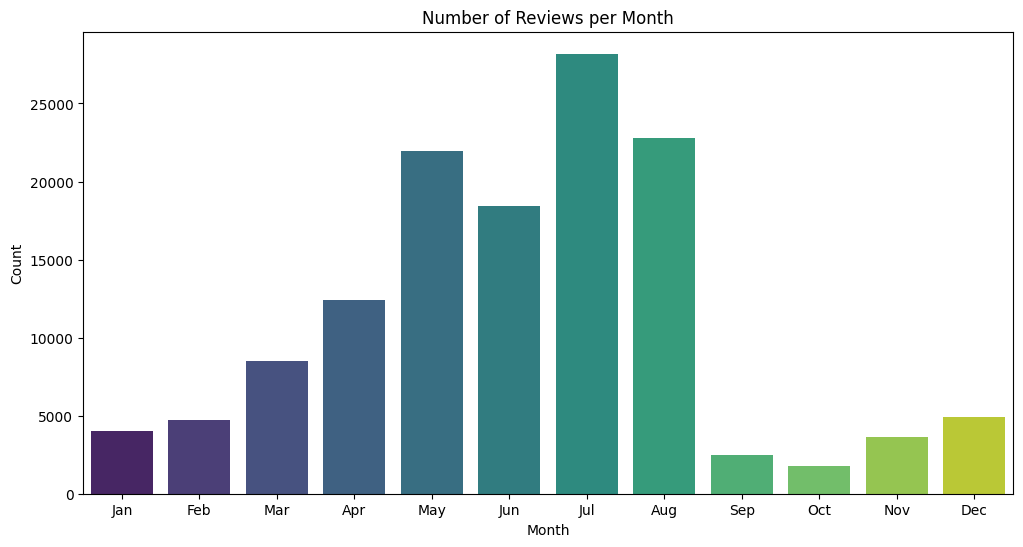

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='month', palette='viridis')
plt.title('Number of Reviews per Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(ticks=np.arange(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

#### **Interpretation: Number of Reviews per Month**
This bar chart shows a clear peak in the number of reviews during July and August. There's a significant increase in review activity during these months compared to earlier in the year. This could be due to various factors like marketing campaigns, new feature releases, or seasonal usage patterns, leading to increased user engagement and feedback.

In [ ]:
def get_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

In [ ]:
df["Sentiment"] = df["Ratings"].apply(get_sentiment)

/tmp/ipykernel_1400/3416178963.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment', palette='coolwarm', order=['Negative', 'Neutral', 'Positive'])


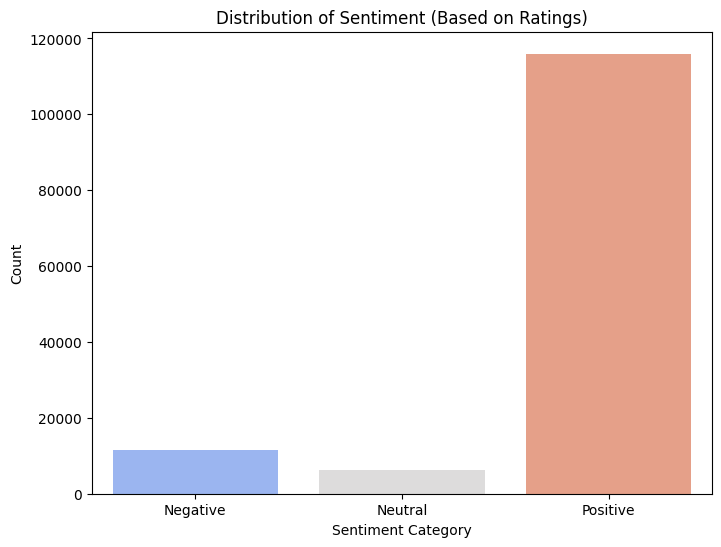

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Sentiment', palette='coolwarm', order=['Negative', 'Neutral', 'Positive'])
plt.title('Distribution of Sentiment (Based on Ratings)')
plt.xlabel('Sentiment Category')
plt.ylabel('Count')
plt.show()

#### **Interpretation: Distribution of Sentiment (Based on Ratings)**
Consistent with the 'Distribution of Review Ratings' graph, this chart confirms that the overwhelming majority of reviews are positive. Negative reviews form the second-largest category, while neutral reviews are the least common. This reinforces the idea of a bimodal sentiment distribution, where extreme positive feedback far outweighs negative feedback, and moderate opinions are rare.

/tmp/ipykernel_1400/3291570204.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=negative_sentiments_df, x='month', palette='Reds')


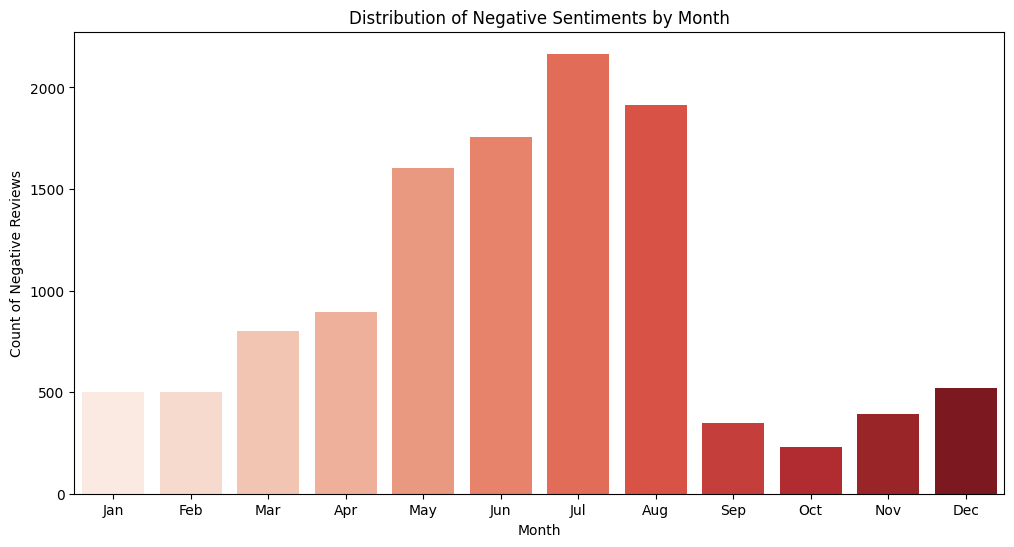

In [ ]:
# Filter for negative sentiments
negative_sentiments_df = df[df['Sentiment'] == 'Negative']

# Plot the count of negative sentiments by month
plt.figure(figsize=(12, 6))
sns.countplot(data=negative_sentiments_df, x='month', palette='Reds')
plt.title('Distribution of Negative Sentiments by Month')
plt.xlabel('Month')
plt.ylabel('Count of Negative Reviews')
plt.xticks(ticks=np.arange(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

#### **Interpretation: Distribution of Negative Sentiments by Month**
This graph reveals that while positive reviews dominate, the count of negative reviews also peaked in July and August. This suggests that the overall increase in review activity during these months affected both positive and negative feedback. Even with higher volumes, the proportion of negative reviews might still be small relative to positive ones, but the absolute number of negative comments was highest in these summer months.

/tmp/ipykernel_1400/3264480812.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sentiment_comparison_df, x='Sentiment', y='review_length', palette={'Negative': 'red', 'Positive': 'green'})


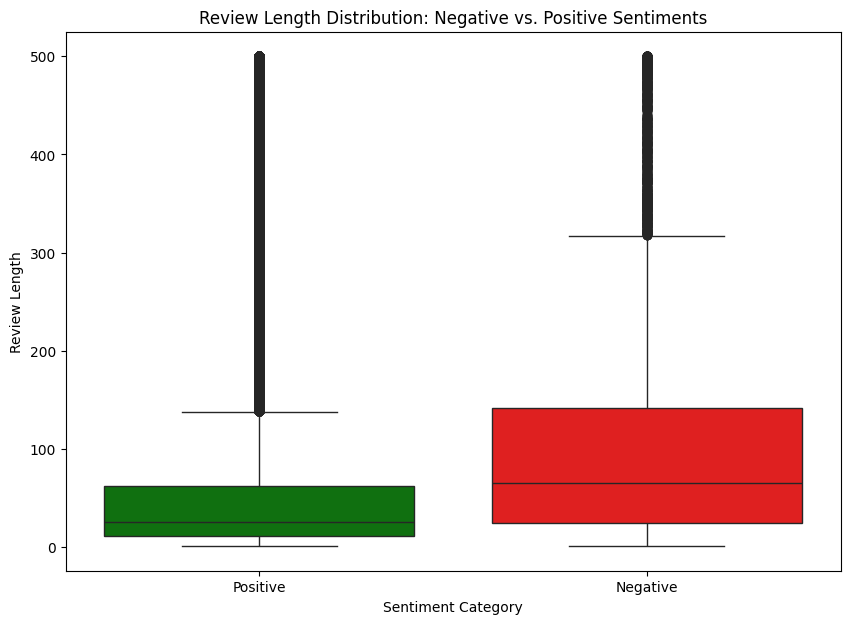

In [ ]:
# Filter for negative and positive sentiments
sentiment_comparison_df = df[df['Sentiment'].isin(['Negative', 'Positive'])]

# Create a boxplot to compare review lengths
plt.figure(figsize=(10, 7))
sns.boxplot(data=sentiment_comparison_df, x='Sentiment', y='review_length', palette={'Negative': 'red', 'Positive': 'green'})
plt.title('Review Length Distribution: Negative vs. Positive Sentiments')
plt.xlabel('Sentiment Category')
plt.ylabel('Review Length')
plt.show()

#### **Interpretation: Review Length Distribution: Negative vs. Positive Sentiments**
The box plot shows a notable difference in review lengths between negative and positive sentiments. Negative reviews tend to be longer on average, with a wider spread (larger interquartile range and more outliers) compared to positive reviews. This suggests that users who leave negative feedback often provide more detailed explanations or grievances, whereas positive feedback is often shorter and more concise.

In [ ]:
# Import Counter
from collections import Counter
import string

# Step 1: Filter only negative reviews
negative_reviews = df[df["Sentiment"] == "Negative"]

# Step 2: Extract the Review column
reviews = negative_reviews["Review"]

# Step 3 & 4: Convert to lowercase and remove punctuation
reviews = reviews.str.lower().str.translate(str.maketrans('', '', string.punctuation))

# Step 5 & 6: Split reviews into words and combine them into one list
words = []

for review in reviews:
    words.extend(review.split())

# Step 7: Remove common stop words
stop_words = {
    "the", "is", "and", "to", "of", "a", "an", "in", "for",
    "it", "this", "that", "i", "my", "on", "with", "was",
    "are", "be", "as", "at", "have", "has", "had", "but",
    "so", "if", "or", "not", "you", "your", "they", "their",
    "we", "our", "its", "can", "could", "would", "should"
}

filtered_words = [word for word in words if word not in stop_words]

# Step 8: Count word frequencies
word_counts = Counter(filtered_words)

# Display the 20 most common words
top_20_words = word_counts.most_common(20)

print(top_20_words)

[('app', 3854), ('me', 1512), ('cant', 1437), ('good', 1218), ('very', 1156), ('when', 1078), ('use', 1022), ('even', 968), ('doesnt', 932), ('just', 928), ('no', 887), ('time', 866), ('chatgpt', 865), ('error', 833), ('dont', 816), ('please', 797), ('like', 792), ('ai', 790), ('working', 789), ('all', 768)]


In [ ]:
top_words_df = pd.DataFrame(top_20_words, columns=["Word", "Frequency"])

top_words_df

,Word,Frequency
0,app,3854
1,me,1512
2,cant,1437
3,good,1218
4,very,1156
5,when,1078
6,use,1022
7,even,968
8,doesnt,932
9,just,928


In [ ]:
july_negative = df[
    (df["Sentiment"] == "Negative") &
    (df["Review Date"].dt.month == 7)
]

In [ ]:
from collections import Counter
import string

reviews = reviews.str.lower().str.translate(
    str.maketrans('', '', string.punctuation)
)

In [ ]:
words = []

for review in reviews:
    words.extend(review.split())

In [ ]:
stop_words = {
    "the","is","and","to","of","a","an","in","for",
    "it","this","that","i","my","on","with","was",
    "are","be","as","at","have","has","had","but",
    "so","if","or","not","you","your","they","their",
    "we","our","its","can","could","would","should"
}

filtered_words = [
    word for word in words
    if word not in stop_words
]

In [ ]:
word_counts = Counter(filtered_words)

In [ ]:
top_20 = word_counts.most_common(20)

top_words_df = pd.DataFrame(
    top_20,
    columns=["Word", "Frequency"]
)

top_words_df

,Word,Frequency
0,app,3854
1,me,1512
2,cant,1437
3,good,1218
4,very,1156
5,when,1078
6,use,1022
7,even,968
8,doesnt,932
9,just,928


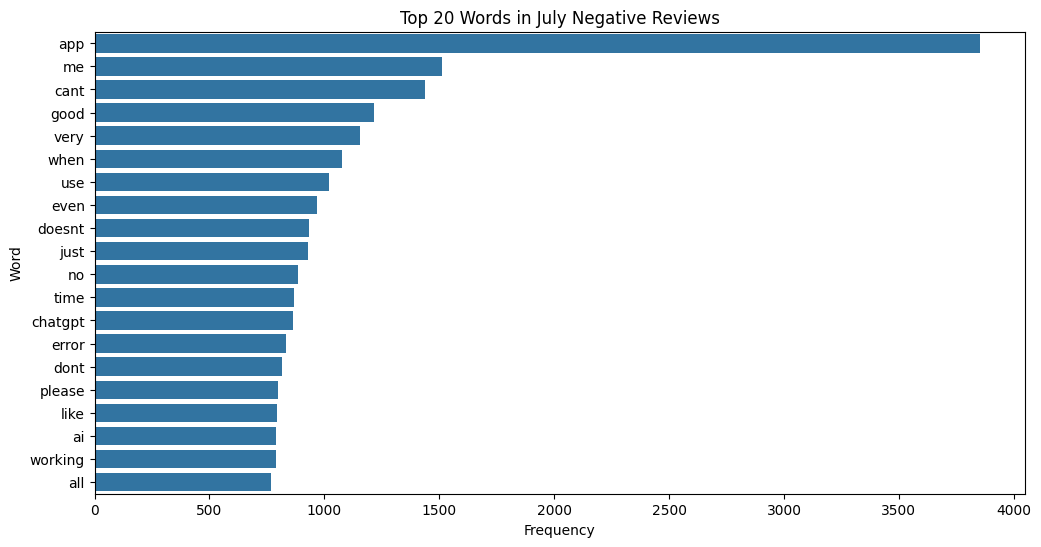

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_words_df,
    x="Frequency",
    y="Word"
)

plt.title("Top 20 Words in July Negative Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

#### **Interpretation: Top 20 Words in July Negative Reviews**
This bar chart highlights the most frequent words in negative reviews specifically from July. Words like 'app', 'cant', 'use', 'doesnt', 'error', and 'working' frequently appear. This indicates common themes of technical issues, app functionality problems, and general dissatisfaction with the app's performance. The high frequency of 'app' suggests many comments are directly about the application itself, while 'cant' and 'doesnt' point to inability to perform desired actions.

#### **Final Conclusion:**

The analysis of the ChatGPT app reviews reveals a highly polarized user sentiment, with an overwhelming majority of 5-star positive ratings alongside a significant number of 1-star negative ratings, and very few neutral or moderately positive reviews. This suggests that users either love the app or are highly dissatisfied, with little middle ground.

Most reviews are concise, but negative reviews tend to be longer and more detailed, indicating that users with grievances are more inclined to provide extensive feedback. There was a notable surge in review activity, both positive and negative, during July and August, potentially linked to app updates, marketing, or seasonal usage patterns.

Key issues highlighted in negative reviews from July frequently revolved around technical problems and functionality, with common terms like 'app', 'cant', 'use', 'doesnt', 'error', and 'working' suggesting user frustration with the app's performance and accessibility. These insights provide valuable direction for product improvements, particularly focusing on stability and core functionality during peak usage periods.